# Ningaloo Niño Index: climatology sensitivity experiment

This notebook calculates the Ningaloo Niño Index (NNI) from ERA5 monthly SST under two climatological-reference experiments. It retains the original common 1981–2025 climatology method and directly compares it with a P1/P2-specific climatology method. All primary NNI values are in °C.

## 1. Scientific definition and references

Ningaloo Niño (and the cold-phase Ningaloo Niña) describes anomalous SST warming (cooling) off Western Australia. The NNI is the cosine-latitude-weighted area-mean SST anomaly: $NNI(t)=\sum SST'(x,y,t)\cos(\phi)/\sum\cos(\phi)$, where $\phi$ is latitude and valid ocean SST cells only are included. Monthly anomaly is $SST'(x,y,t)=SST(x,y,t)-\overline{SST}_{month}(x,y)$.

The method is based on Kataoka, T., Behera, S. K., & Yamagata, T. (2014), *On the Ningaloo Niño/Niña*, Climate Dynamics, 43, 1463–1482. DOI: https://doi.org/10.1007/s00382-013-1961-z. Input SST is ERA5 monthly sea-surface temperature from ECMWF. Calendar-month anomalies remove the normal seasonal cycle. DJF is labelled by its January/February year, so DJF 1981 is December 1980 plus January and February 1981.

The operational Ningaloo domain is 28–22°S and 108–116°E, a rectangular ERA5-grid implementation of the requested 108°E-to-Western-Australian-coast sector. Land or missing SST cells are excluded. SST is not detrended or standardized before anomalies.

## 2. Climatology experiments and interpretation

**Experiment 1 — common climatology.** One 1981–2025 calendar-month SST climatology is applied to every month, including December 1980 with the 1981–2025 December climatology. This retains mean-state SST differences between P1 (1981–2006) and P2 (2007–2025), because both periods share one baseline.

**Experiment 2 — period specific climatology.** Separate calendar-month climatologies are calculated for P1 and P2. P1 values, including December 1980 support, use P1 climatology; P2 values use P2 climatology. This removes the mean climatological SST difference between P1 and P2, leaving departures relative to each period’s own climate.

Each experiment has independent monthly anomalies, DJF NNI, full-series sample standard deviation, standardized NNI, and event classification. For the period-specific experiment, sigma P1 and sigma P2 are also reported. Its primary classification deliberately uses one combined 1981–2025 period-specific sigma, enabling a directly comparable P1/P2 threshold. This is a robustness/sensitivity test, not evidence of causality: persistence of P1/P2 differences after period-specific anomalies would make a simple mean SST shift a less likely explanation, but cannot establish a cause.

## 3. Load and inspect ERA5 input data

The file layout is inspected rather than assumed. The code prints dimensions, variables, SST units, coordinate ranges, and timestamp coverage, then checks the assembled monthly record for duplicated or missing months without interpolating.

In [1]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings('ignore', category=FutureWarning)
INPUT_DIR = Path('/Users/rizzie/ClimateData/era5-monthly')
OUTPUT_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Supplement/Ningaloo')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FILES = [INPUT_DIR / name for name in ['sst_DJF_1980-2025.nc','sst_MAM_1980-2025.nc','sst_JJA_1980-2025.nc','sst_SON_1980-2025.nc']]
CLIM_START, CLIM_END = '1981-01-01', '2025-12-31'
P1_START, P1_END = '1981-01-01', '2006-12-31'
P2_START, P2_END = '2007-01-01', '2025-12-31'
ANALYSIS_START, ANALYSIS_END = '1980-12-01', '2025-12-31'
LAT_BOUNDS, LON_BOUNDS = (-28.0, -22.0), (108.0, 116.0)
if missing := [str(file) for file in FILES if not file.exists()]: raise FileNotFoundError(f'Missing ERA5 file(s): {missing}')

def find_coord(ds, choices):
    lookup = {name.lower(): name for name in ds.coords}
    for choice in choices:
        if choice in lookup: return lookup[choice]
    for name in ds.coords:
        if ds[name].attrs.get('standard_name','').lower() in choices: return name
    raise KeyError(f'Could not find {choices}; coordinates are {list(ds.coords)}')

def find_sst(ds):
    if 'sst' in ds.data_vars: return 'sst'
    for name, data in ds.data_vars.items():
        text = ' '.join([name,data.attrs.get('standard_name',''),data.attrs.get('long_name','')]).lower()
        if 'sea_surface_temperature' in text or 'sea surface temperature' in text or name.lower() == 'tos': return name
    raise KeyError(f'Could not identify SST; variables are {list(ds.data_vars)}')

datasets, records = [], []
for file in FILES:
    ds = xr.open_dataset(file); datasets.append(ds)
    sst, lat, lon, time = find_sst(ds), find_coord(ds,['latitude','lat']), find_coord(ds,['longitude','lon']), find_coord(ds,['valid_time','time'])
    row = {'file':file.name,'dimensions':dict(ds.sizes),'variables':list(ds.data_vars),'sst_variable':sst,'sst_units':ds[sst].attrs.get('units','not specified'),'latitude_range':(float(ds[lat].min()),float(ds[lat].max())),'longitude_range':(float(ds[lon].min()),float(ds[lon].max())),'first_timestamp':str(pd.Timestamp(ds[time].values.min()).date()),'last_timestamp':str(pd.Timestamp(ds[time].values.max()).date())}
    records.append(row); print('\n' + file.name)
    for key,value in row.items():
        if key != 'file': print(f'  {key}: {value}')
inspection = pd.DataFrame(records)
inspection


sst_DJF_1980-2025.nc
  dimensions: {'valid_time': 138, 'latitude': 721, 'longitude': 1440}
  variables: ['sst']
  sst_variable: sst
  sst_units: K
  latitude_range: (-90.0, 90.0)
  longitude_range: (0.0, 359.75)
  first_timestamp: 1980-01-01
  last_timestamp: 2025-12-01

sst_MAM_1980-2025.nc
  dimensions: {'valid_time': 138, 'latitude': 721, 'longitude': 1440}
  variables: ['sst']
  sst_variable: sst
  sst_units: K
  latitude_range: (-90.0, 90.0)
  longitude_range: (0.0, 359.75)
  first_timestamp: 1980-03-01
  last_timestamp: 2025-05-01

sst_JJA_1980-2025.nc
  dimensions: {'valid_time': 138, 'latitude': 721, 'longitude': 1440}
  variables: ['sst']
  sst_variable: sst
  sst_units: K
  latitude_range: (-90.0, 90.0)
  longitude_range: (0.0, 359.75)
  first_timestamp: 1980-06-01
  last_timestamp: 2025-08-01

sst_SON_1980-2025.nc
  dimensions: {'valid_time': 138, 'latitude': 721, 'longitude': 1440}
  variables: ['sst']
  sst_variable: sst
  sst_units: K
  latitude_range: (-90.0, 90.0)
  lo

,file,dimensions,variables,sst_variable,sst_units,latitude_range,longitude_range,first_timestamp,last_timestamp
0,sst_DJF_1980-2025.nc,"{'valid_time': 138, 'latitude': 721, 'longitud...",[sst],sst,K,"(-90.0, 90.0)","(0.0, 359.75)",1980-01-01,2025-12-01
1,sst_MAM_1980-2025.nc,"{'valid_time': 138, 'latitude': 721, 'longitud...",[sst],sst,K,"(-90.0, 90.0)","(0.0, 359.75)",1980-03-01,2025-05-01
2,sst_JJA_1980-2025.nc,"{'valid_time': 138, 'latitude': 721, 'longitud...",[sst],sst,K,"(-90.0, 90.0)","(0.0, 359.75)",1980-06-01,2025-08-01
3,sst_SON_1980-2025.nc,"{'valid_time': 138, 'latitude': 721, 'longitud...",[sst],sst,K,"(-90.0, 90.0)","(0.0, 359.75)",1980-09-01,2025-11-01


## 4. Prepare continuous SST and select valid Ningaloo ocean cells

SST is renamed to common coordinate names, concatenated, sorted, converted from Kelvin to °C when required, and normalized to a 0–360° longitude convention. December 1980 through December 2025 are retained. The range masks do not depend on latitude ordering. SST is subset to the modest NNI domain before climatologies are computed, which keeps the calculation reproducible and efficient without changing the area-mean index.

Combined dimensions: {'time': 552, 'lat': 721, 'lon': 1440}
First / last: 1980-01-01 00:00:00 / 2025-12-01 00:00:00
Duplicate timestamps: []
Missing timestamps: []


Converted SST from Kelvin to °C.


Retained analysis period: 1980-12-01 to 2025-12-01
Exact grid domain: -28.00 to -22.00°N, 108.00 to 116.00°E; valid ocean cells: 598


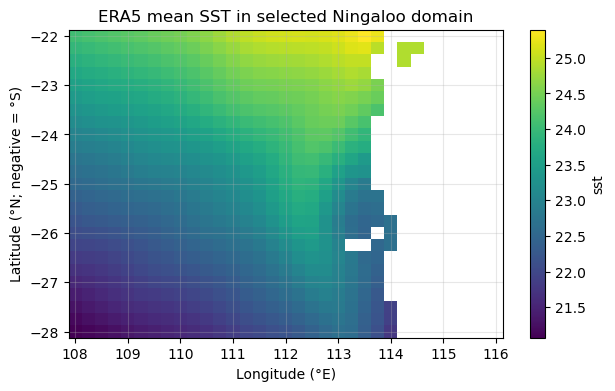

In [2]:
def standard_sst(ds):
    rename = {find_coord(ds,['valid_time','time']):'time',find_coord(ds,['latitude','lat']):'lat',find_coord(ds,['longitude','lon']):'lon'}
    return ds[find_sst(ds)].rename(rename).rename('sst').transpose('time','lat','lon')

sst_raw = xr.concat([standard_sst(ds) for ds in datasets],dim='time').sortby('time')
times = pd.DatetimeIndex(sst_raw.time.values)
duplicates = times[times.duplicated(keep=False)]
expected = pd.date_range(times.min().to_period('M').to_timestamp(),times.max().to_period('M').to_timestamp(),freq='MS')
observed = pd.DatetimeIndex(times.to_period('M').to_timestamp()).unique().sort_values()
missing_months = expected.difference(observed)
print('Combined dimensions:',dict(sst_raw.sizes)); print('First / last:',times.min(),'/',times.max())
print('Duplicate timestamps:',list(duplicates)); print('Missing timestamps:',[item.strftime('%Y-%m-%d') for item in missing_months])
if len(duplicates) or len(missing_months): raise ValueError('Duplicate or missing months found; no interpolation is permitted.')
units = str(sst_raw.attrs.get('units','')).strip().lower()
if units in {'k','kelvin','degrees_kelvin','degree_kelvin'}:
    sst_c = (sst_raw - 273.15).assign_attrs({**sst_raw.attrs,'units':'degC'}); print('Converted SST from Kelvin to °C.')
elif units in {'c','degc','degree_celsius','degrees_celsius','celsius','°c'}:
    sst_c = sst_raw.assign_attrs({**sst_raw.attrs,'units':'degC'}); print('SST already in °C.')
else: raise ValueError(f'Unrecognised SST units: {sst_raw.attrs.get(chr(39))!r}')
sst_c = sst_c.assign_coords(lon=(sst_c.lon % 360).astype(float)).sortby('lon')
sst_analysis = sst_c.sel(time=slice(ANALYSIS_START,ANALYSIS_END))
lat_mask = (sst_analysis.lat >= min(LAT_BOUNDS)) & (sst_analysis.lat <= max(LAT_BOUNDS))
lon_mask = (sst_analysis.lon >= min(LON_BOUNDS)) & (sst_analysis.lon <= max(LON_BOUNDS))
sst_region = sst_analysis.where(lat_mask & lon_mask,drop=True)
ocean_cells = sst_region.notnull().any('time')
sst_region = sst_region.where(ocean_cells)
n_valid_cells = int(ocean_cells.sum().item())
if n_valid_cells == 0: raise ValueError('No valid ocean SST cells in the selected Ningaloo domain.')
print('Retained analysis period:',str(sst_region.time.values[0])[:10],'to',str(sst_region.time.values[-1])[:10])
print(f'Exact grid domain: {float(sst_region.lat.min()):.2f} to {float(sst_region.lat.max()):.2f}°N, {float(sst_region.lon.min()):.2f} to {float(sst_region.lon.max()):.2f}°E; valid ocean cells: {n_valid_cells}')
fig,ax = plt.subplots(figsize=(7,4))
sst_region.mean('time',skipna=True).plot(ax=ax,x='lon',y='lat',cmap='viridis')
ax.set(title='ERA5 mean SST in selected Ningaloo domain',xlabel='Longitude (°E)',ylabel='Latitude (°N; negative = °S)'); ax.grid(alpha=.3); plt.show()

## 5. Calculate both monthly-NNI experiments

The first branch is the original common 1981–2025 climatology calculation. The second branch applies the P1 climatology to December 1980–December 2006 and P2 climatology to January 2007–December 2025. Both branches use the same valid-ocean mask and cosine-latitude spatial weighting, but their anomalies are never mixed.

Wrote monthly outputs: ningaloo_nino_index_monthly_common_climatology_1980-2025.csv ningaloo_nino_index_monthly_period_specific_climatology_1980-2025.csv


,date,year,month,period,nni,climatology_experiment
0,1980-12-01,1980,12,P1_support,-0.555569,common_climatology
1,1981-01-01,1981,1,P1,-1.022119,common_climatology
2,1981-02-01,1981,2,P1,-1.048022,common_climatology
3,1981-03-01,1981,3,P1,-0.574014,common_climatology
4,1981-04-01,1981,4,P1,-0.700741,common_climatology


,date,year,month,period,nni,climatology_experiment
0,1980-12-01,1980,12,P1_support,-0.256209,period_specific_climatology
1,1981-01-01,1981,1,P1,-0.670490,period_specific_climatology
2,1981-02-01,1981,2,P1,-0.773277,period_specific_climatology
3,1981-03-01,1981,3,P1,-0.332833,period_specific_climatology
4,1981-04-01,1981,4,P1,-0.509393,period_specific_climatology


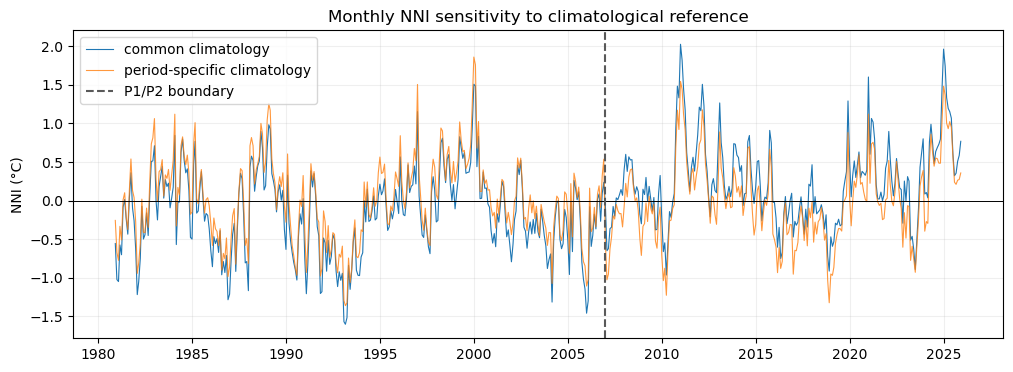

In [3]:
def period_label(year, support=False):
    if support and year == 1980: return 'P1_support'
    return 'P1' if year <= 2006 else 'P2'

def monthly_index(anomaly, experiment):
    weights = np.cos(np.deg2rad(anomaly.lat))
    index = anomaly.weighted(weights).mean(('lat','lon'),skipna=True).rename('nni')
    frame = index.to_dataframe().reset_index(); frame['date'] = pd.to_datetime(frame.time)
    frame['year'],frame['month'] = frame.date.dt.year,frame.date.dt.month
    frame['period'] = [period_label(year,True) for year in frame.year]
    frame['climatology_experiment'] = experiment
    return frame[['date','year','month','period','nni','climatology_experiment']].sort_values('date').reset_index(drop=True)

common_climatology = sst_region.sel(time=slice(CLIM_START,CLIM_END)).groupby('time.month').mean('time',skipna=True)
common_anomaly = sst_region.groupby('time.month') - common_climatology
p1_climatology = sst_region.sel(time=slice(P1_START,P1_END)).groupby('time.month').mean('time',skipna=True)
p2_climatology = sst_region.sel(time=slice(P2_START,P2_END)).groupby('time.month').mean('time',skipna=True)
p1_anomaly = sst_region.sel(time=slice(ANALYSIS_START,P1_END)).groupby('time.month') - p1_climatology
p2_anomaly = sst_region.sel(time=slice(P2_START,P2_END)).groupby('time.month') - p2_climatology
specific_anomaly = xr.concat([p1_anomaly,p2_anomaly],dim='time').sortby('time')
monthly_common = monthly_index(common_anomaly,'common_climatology')
monthly_specific = monthly_index(specific_anomaly,'period_specific_climatology')
monthly_paths = {'common_climatology':OUTPUT_DIR/'ningaloo_nino_index_monthly_common_climatology_1980-2025.csv','period_specific_climatology':OUTPUT_DIR/'ningaloo_nino_index_monthly_period_specific_climatology_1980-2025.csv'}
monthly_common.to_csv(monthly_paths['common_climatology'],index=False)
monthly_specific.to_csv(monthly_paths['period_specific_climatology'],index=False)
print('Wrote monthly outputs:',*[path.name for path in monthly_paths.values()])
display(monthly_common.head(),monthly_specific.head())
fig,ax = plt.subplots(figsize=(12,4))
ax.plot(monthly_common.date,monthly_common.nni,label='common climatology',lw=.8)
ax.plot(monthly_specific.date,monthly_specific.nni,label='period-specific climatology',lw=.8,alpha=.8)
ax.axhline(0,color='black',lw=.7); ax.axvline(pd.Timestamp('2007-01-01'),color='0.35',ls='--',label='P1/P2 boundary')
ax.set(title='Monthly NNI sensitivity to climatological reference',ylabel='NNI (°C)'); ax.grid(alpha=.2); ax.legend(); plt.show()

## 6. Calculate DJF NNI, sigma, and classifications independently

For each experiment, DJF(Y) is the mean of December(Y−1), January(Y), and February(Y). Every season is explicitly checked for three values, yielding 45 seasons for 1981–2025. Each experiment gets its own combined-series sample standard deviation with ddof = 1 and its own standardized NNI. The period-specific primary classification uses its own combined 1981–2025 sigma, not sigma P1 or sigma P2.

In [4]:
def djf_index(monthly,experiment):
    series = monthly.set_index('date').nni.sort_index(); rows = []
    for year in range(1981,2026):
        dates = pd.to_datetime([f'{year-1}-12-01',f'{year}-01-01',f'{year}-02-01'])
        values = series.reindex(dates)
        if len(values) != 3 or values.isna().any(): raise ValueError(f'{experiment} DJF {year} incomplete: {values.to_dict()}')
        rows.append({'year':year,'period':period_label(year),'dec_nni':values.iloc[0],'jan_nni':values.iloc[1],'feb_nni':values.iloc[2],'nni_djf':values.mean(),'n_months':len(values)})
    frame = pd.DataFrame(rows)
    if len(frame) != 45 or not (frame.n_months == 3).all(): raise AssertionError(f'{experiment} must contain 45 complete DJF seasons.')
    sigma = frame.nni_djf.std(ddof=1)
    frame['sigma'] = sigma; frame['standardized_nni'] = frame.nni_djf / sigma
    frame['classification'] = np.select([frame.nni_djf > sigma,frame.nni_djf < -sigma],['Ningaloo Nino','Ningaloo Nina'],default='Neutral')
    frame['climatology_experiment'] = experiment
    return frame[['year','period','dec_nni','jan_nni','feb_nni','nni_djf','sigma','standardized_nni','classification','climatology_experiment','n_months']],sigma

djf_common,sigma_common = djf_index(monthly_common,'common_climatology')
djf_specific,sigma_specific = djf_index(monthly_specific,'period_specific_climatology')
sigma_p1 = djf_specific.loc[djf_specific.period.eq('P1'),'nni_djf'].std(ddof=1)
sigma_p2 = djf_specific.loc[djf_specific.period.eq('P2'),'nni_djf'].std(ddof=1)
djf_paths = {'common_climatology':OUTPUT_DIR/'ningaloo_nino_index_DJF_common_climatology_1981-2025.csv','period_specific_climatology':OUTPUT_DIR/'ningaloo_nino_index_DJF_period_specific_climatology_1981-2025.csv'}
djf_common.to_csv(djf_paths['common_climatology'],index=False); djf_specific.to_csv(djf_paths['period_specific_climatology'],index=False)
print(f'Common-climatology sigma: {sigma_common:.3f} °C')
print(f'Period-specific combined sigma: {sigma_specific:.3f} °C; sigma_P1: {sigma_p1:.3f} °C; sigma_P2: {sigma_p2:.3f} °C')
for name,frame in [('common',djf_common),('period-specific',djf_specific)]:
    nino = frame.loc[frame.classification.eq('Ningaloo Nino'),'year'].tolist(); nina = frame.loc[frame.classification.eq('Ningaloo Nina'),'year'].tolist()
    print(f'{name}: Nino {nino}; Nina {nina}')
display(djf_common.head(),djf_specific.head())

Common-climatology sigma: 0.715 °C
Period-specific combined sigma: 0.610 °C; sigma_P1: 0.617 °C; sigma_P2: 0.618 °C
common: Nino [2000, 2011, 2012, 2021, 2025]; Nina [1981, 1987, 1992, 1993, 1994, 2004, 2006]
period-specific: Nino [1983, 1984, 1989, 1997, 2000, 2011, 2012, 2025]; Nina [1987, 1993, 2006, 2017, 2019]


,year,period,dec_nni,jan_nni,feb_nni,nni_djf,sigma,standardized_nni,classification,climatology_experiment,n_months
0,1981,P1,-0.555569,-1.022119,-1.048022,-0.875236,0.714791,-1.224464,Ningaloo Nina,common_climatology,3
1,1982,P1,-0.259240,-0.623286,-1.216758,-0.699762,0.714791,-0.978973,Neutral,common_climatology,3
2,1983,P1,0.513617,0.711098,0.002445,0.409054,0.714791,0.572270,Neutral,common_climatology,3
3,1984,P1,0.029219,0.174121,0.844777,0.349372,0.714791,0.488775,Neutral,common_climatology,3
4,1985,P1,-0.476310,-0.497963,0.464104,-0.170056,0.714791,-0.237911,Neutral,common_climatology,3


,year,period,dec_nni,jan_nni,feb_nni,nni_djf,sigma,standardized_nni,classification,climatology_experiment,n_months
0,1981,P1,-0.256209,-0.670490,-0.773277,-0.566659,0.610308,-0.928479,Neutral,period_specific_climatology,3
1,1982,P1,0.040120,-0.271657,-0.942014,-0.391184,0.610308,-0.640961,Neutral,period_specific_climatology,3
2,1983,P1,0.812977,1.062728,0.277190,0.717631,0.610308,1.175850,Ningaloo Nino,period_specific_climatology,3
3,1984,P1,0.328579,0.525750,1.119521,0.657950,0.610308,1.078061,Ningaloo Nino,period_specific_climatology,3
4,1985,P1,-0.176951,-0.146334,0.738849,0.138521,0.610308,0.226969,Neutral,period_specific_climatology,3


## 7. Sensitivity to climatological reference period

These diagnostics assess whether the definition changes DJF values or event classifications. A vertical line marks the P1/P2 boundary between 2006 and 2007. The difference is period-specific minus common. The classifications should be interpreted as a robustness comparison, not a causal attribution.

Wrote ningaloo_nino_index_DJF_climatology_comparison_1981-2025.csv


,year,period,nni_djf_common,nni_djf_period_specific,difference_period_specific_minus_common,standardized_nni_common,standardized_nni_period_specific,classification_common,classification_period_specific,classification_changed
0,1981,P1,-0.875236,-0.566659,0.308578,-1.224464,-0.928479,Ningaloo Nina,Neutral,True
2,1983,P1,0.409054,0.717631,0.308578,0.572270,1.175850,Neutral,Ningaloo Nino,True
3,1984,P1,0.349372,0.657950,0.308578,0.488775,1.078061,Neutral,Ningaloo Nino,True
8,1989,P1,0.622589,0.931166,0.308578,0.871008,1.525731,Neutral,Ningaloo Nino,True
11,1992,P1,-0.737039,-0.428461,0.308578,-1.031124,-0.702040,Ningaloo Nina,Neutral,True
13,1994,P1,-0.791588,-0.483010,0.308578,-1.107440,-0.791420,Ningaloo Nina,Neutral,True
16,1997,P1,0.476475,0.785053,0.308578,0.666593,1.286321,Neutral,Ningaloo Nino,True
23,2004,P1,-0.777871,-0.469293,0.308578,-1.088249,-0.768944,Ningaloo Nina,Neutral,True
36,2017,P2,-0.214429,-0.636724,-0.422295,-0.299988,-1.043282,Neutral,Ningaloo Nina,True
38,2019,P2,-0.657611,-1.079905,-0.422295,-0.920004,-1.769442,Neutral,Ningaloo Nina,True


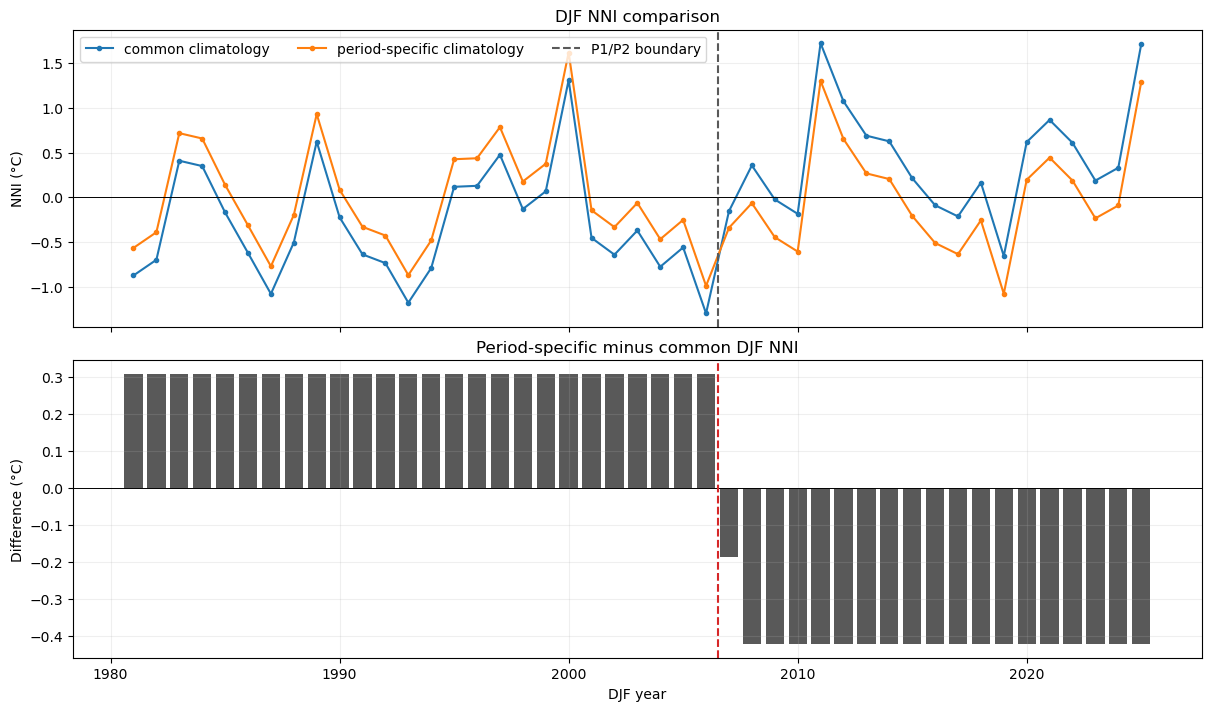

In [5]:
comparison = djf_common[['year','period','nni_djf','standardized_nni','classification']].merge(djf_specific[['year','nni_djf','standardized_nni','classification']],on='year',suffixes=('_common','_period_specific'))
comparison['difference_period_specific_minus_common'] = comparison.nni_djf_period_specific - comparison.nni_djf_common
comparison['classification_changed'] = comparison.classification_common != comparison.classification_period_specific
comparison = comparison[['year','period','nni_djf_common','nni_djf_period_specific','difference_period_specific_minus_common','standardized_nni_common','standardized_nni_period_specific','classification_common','classification_period_specific','classification_changed']]
comparison_path = OUTPUT_DIR/'ningaloo_nino_index_DJF_climatology_comparison_1981-2025.csv'
comparison.to_csv(comparison_path,index=False)
changed = comparison[comparison.classification_changed]
print(f'Wrote {comparison_path.name}')
if changed.empty: print('No event classifications changed between climatology experiments.')
else: display(changed)

fig,axes = plt.subplots(2,1,figsize=(12,7),sharex=True,layout='constrained')
axes[0].plot(comparison.year,comparison.nni_djf_common,label='common climatology',marker='o',ms=3)
axes[0].plot(comparison.year,comparison.nni_djf_period_specific,label='period-specific climatology',marker='o',ms=3)
axes[0].axhline(0,color='black',lw=.7); axes[0].axvline(2006.5,color='0.35',ls='--',label='P1/P2 boundary')
axes[0].set(title='DJF NNI comparison',ylabel='NNI (°C)'); axes[0].grid(alpha=.2); axes[0].legend(ncol=3)
axes[1].axhline(0,color='black',lw=.7); axes[1].bar(comparison.year,comparison.difference_period_specific_minus_common,color='0.35')
axes[1].axvline(2006.5,color='tab:red',ls='--'); axes[1].set(title='Period-specific minus common DJF NNI',xlabel='DJF year',ylabel='Difference (°C)'); axes[1].grid(alpha=.2)
plt.show()

## 8. P1/P2 summary, validation, and conclusion

The summary quantifies P1/P2 mean, sample standard deviation, range, and event counts for each experiment. Validation confirms the calendar-month anomaly property within each experiment’s relevant reference period, input time integrity, DJF endpoints, 45 complete seasons, valid ocean selection, and clean CSV columns. The final printed conclusion reports whether values and classifications changed and whether P1/P2 differences persist after period-specific mean removal.

In [6]:
def period_summary(frame,experiment):
    rows = []
    for period,part in frame.groupby('period',sort=False):
        rows.append({'climatology_experiment':experiment,'period':period,'mean_djf_nni':part.nni_djf.mean(),'std_djf_nni_ddof1':part.nni_djf.std(ddof=1),'min_djf_nni':part.nni_djf.min(),'max_djf_nni':part.nni_djf.max(),'n_nino':int(part.classification.eq('Ningaloo Nino').sum()),'n_nina':int(part.classification.eq('Ningaloo Nina').sum()),'n_neutral':int(part.classification.eq('Neutral').sum()),'n_years':len(part)})
    return rows
summary = pd.DataFrame(period_summary(djf_common,'common_climatology') + period_summary(djf_specific,'period_specific_climatology'))
summary_path = OUTPUT_DIR/'ningaloo_nino_climatology_experiment_summary.csv'
summary.to_csv(summary_path,index=False); display(summary)

common_residual = float(np.abs(common_anomaly.sel(time=slice(CLIM_START,CLIM_END)).groupby('time.month').mean('time',skipna=True)).max().item())
p1_residual = float(np.abs(p1_anomaly.sel(time=slice(P1_START,P1_END)).groupby('time.month').mean('time',skipna=True)).max().item())
p2_residual = float(np.abs(p2_anomaly.groupby('time.month').mean('time',skipna=True)).max().item())
checks = {'common monthly anomaly residual (°C)':common_residual,'P1 monthly anomaly residual (°C)':p1_residual,'P2 monthly anomaly residual (°C)':p2_residual,'no duplicate timestamps':not times.has_duplicates,'missing timestamps':len(missing_months),'DJF 1981 complete':bool((djf_common.loc[djf_common.year.eq(1981),'n_months']==3).all()),'DJF 2025 complete':bool((djf_common.loc[djf_common.year.eq(2025),'n_months']==3).all()),'45 DJF values per experiment':len(djf_common)==45 and len(djf_specific)==45,'all DJF complete':bool((djf_common.n_months.eq(3)&djf_specific.n_months.eq(3)).all()),'valid ocean cells':n_valid_cells,'SST range (°C)':(float(sst_region.min(skipna=True)),float(sst_region.max(skipna=True))),'monthly CSVs no index':all('Unnamed: 0' not in pd.read_csv(path).columns for path in monthly_paths.values()),'DJF CSVs no index':all('Unnamed: 0' not in pd.read_csv(path).columns for path in djf_paths.values()),'comparison CSV no index':'Unnamed: 0' not in pd.read_csv(comparison_path).columns,'summary CSV no index':'Unnamed: 0' not in pd.read_csv(summary_path).columns}
for key,value in checks.items(): print(f'{key}: {value}')
assert max(common_residual,p1_residual,p2_residual) < 5e-5
assert checks['no duplicate timestamps'] and checks['missing timestamps']==0 and checks['DJF 1981 complete'] and checks['DJF 2025 complete'] and checks['45 DJF values per experiment'] and checks['all DJF complete']
assert checks['monthly CSVs no index'] and checks['DJF CSVs no index'] and checks['comparison CSV no index'] and checks['summary CSV no index']
mean_shift_common = summary.loc[summary.climatology_experiment.eq('common_climatology')].groupby('period').mean_djf_nni.mean().diff().iloc[-1]
mean_shift_specific = summary.loc[summary.climatology_experiment.eq('period_specific_climatology')].groupby('period').mean_djf_nni.mean().diff().iloc[-1]
print(f'\nExecuted summary: common sigma={sigma_common:.3f} °C; period-specific combined sigma={sigma_specific:.3f} °C, P1={sigma_p1:.3f} °C, P2={sigma_p2:.3f} °C.')
print(f'DJF values differ by up to {comparison.difference_period_specific_minus_common.abs().max():.3f} °C; classifications changed in {len(changed)} of 45 seasons.')
print(f'P2-minus-P1 mean DJF NNI: common={mean_shift_common:.3f} °C; period-specific={mean_shift_specific:.3f} °C. Interpret this as sensitivity evidence, not causality.')
print('Outputs:',*[path.name for path in [*monthly_paths.values(),*djf_paths.values(),comparison_path,summary_path]])

,climatology_experiment,period,mean_djf_nni,std_djf_nni_ddof1,min_djf_nni,max_djf_nni,n_nino,n_nina,n_neutral,n_years
0,common_climatology,P1,-0.318741,0.617118,-1.300007,1.311173,1,7,18,26
1,common_climatology,P2,0.412984,0.627259,-0.657611,1.724942,4,0,15,19
2,period_specific_climatology,P1,-0.010163,0.617118,-0.991429,1.619751,5,3,18,26
3,period_specific_climatology,P2,0.003128,0.617618,-1.079905,1.302647,3,2,14,19


common monthly anomaly residual (°C): 1.7886692148749717e-05
P1 monthly anomaly residual (°C): 7.922832992335316e-06
P2 monthly anomaly residual (°C): 2.509669229766587e-06
no duplicate timestamps: True
missing timestamps: 0
DJF 1981 complete: True
DJF 2025 complete: True
45 DJF values per experiment: True
all DJF complete: True
valid ocean cells: 598
SST range (°C): (15.644195556640625, 30.851959228515625)
monthly CSVs no index: True
DJF CSVs no index: True
comparison CSV no index: True
summary CSV no index: True

Executed summary: common sigma=0.715 °C; period-specific combined sigma=0.610 °C, P1=0.617 °C, P2=0.618 °C.
DJF values differ by up to 0.422 °C; classifications changed in 11 of 45 seasons.
P2-minus-P1 mean DJF NNI: common=0.732 °C; period-specific=0.013 °C. Interpret this as sensitivity evidence, not causality.
Outputs: ningaloo_nino_index_monthly_common_climatology_1980-2025.csv ningaloo_nino_index_monthly_period_specific_climatology_1980-2025.csv ningaloo_nino_index_DJF_c

## Final executed-results summary

The executed ERA5 calculation used valid ocean cells in the exact 28–22°S, 108–116°E grid rectangle, cosine-latitude weighting, and no interpolation, detrending, or pre-anomaly standardization. December 1980 used the applicable December climatology only to construct DJF 1981.

The common 1981–2025 climatology produced sigma = 0.714791 °C. The period-specific climatology produced combined sigma = 0.610308 °C, with sigma P1 = 0.617118 °C and sigma P2 = 0.617618 °C; primary period-specific classifications use the combined sigma. The monthly and DJF CSVs for both experiments, their DJF comparison CSV, and the P1/P2 summary CSV are saved in this directory.

The two DJF definitions differed by at most 0.422295 °C and changed classification in 11 of 45 seasons. Common-climatology P2-minus-P1 mean DJF NNI was 0.731725 °C, while it was 0.013291 °C after period-specific mean removal. Thus the mean-state shift is important for the P1/P2 contrast, while the remaining period-specific differences should be treated as sensitivity evidence rather than causal attribution.

## 9. Add normal climatology and update to a three-way sensitivity experiment

This extension preserves the existing common and period-specific calculations and adds a third conventional baseline: **normal climatology**, a fixed 1991–2020 30-year calendar-month reference applied to every analysis month, including December 1980. The three final experiment names are **common climatology**, **normal climatology**, and **period specific climatology**.

Common climatology (1981–2025) preserves P1/P2 mean-state differences relative to the full-study-period mean. Normal climatology (1991–2020) provides a conventional, fixed baseline independent of the study period’s endpoints; it is not presumed uniquely correct. Period specific climatology uses P1/P2 baselines and removes their climatological mean difference. This remains a climatology sensitivity experiment, not a test of causality or superiority.

In [7]:
# New experiment: fixed 1991–2020 climatological normal, applied to all months.
NORMAL_START, NORMAL_END = '1991-01-01', '2020-12-31'
normal_reference = sst_region.sel(time=slice(NORMAL_START,NORMAL_END))
if normal_reference.sizes['time'] != 360: raise ValueError('Expected 360 months for the 1991–2020 normal.')
normal_climatology = normal_reference.groupby('time.month').mean('time',skipna=True)
normal_anomaly = sst_region.groupby('time.month') - normal_climatology
monthly_normal = monthly_index(normal_anomaly,'normal climatology')

# Preserve the existing common and period-specific index values, but standardize final metadata names.
monthly_common['climatology_experiment'] = 'common climatology'
monthly_specific['climatology_experiment'] = 'period specific climatology'
monthly_paths = {'common climatology':OUTPUT_DIR/'ningaloo_nino_index_monthly_common_climatology_1980-2025.csv','normal climatology':OUTPUT_DIR/'ningaloo_nino_index_monthly_normal_climatology_1980-2025.csv','period specific climatology':OUTPUT_DIR/'ningaloo_nino_index_monthly_period_specific_climatology_1980-2025.csv'}
for name,frame in [('common climatology',monthly_common),('normal climatology',monthly_normal),('period specific climatology',monthly_specific)]: frame.to_csv(monthly_paths[name],index=False)

djf_common['climatology_experiment'] = 'common climatology'
djf_specific['climatology_experiment'] = 'period specific climatology'
djf_normal,sigma_normal = djf_index(monthly_normal,'normal climatology')
djf_paths = {'common climatology':OUTPUT_DIR/'ningaloo_nino_index_DJF_common_climatology_1981-2025.csv','normal climatology':OUTPUT_DIR/'ningaloo_nino_index_DJF_normal_climatology_1981-2025.csv','period specific climatology':OUTPUT_DIR/'ningaloo_nino_index_DJF_period_specific_climatology_1981-2025.csv'}
for name,frame in [('common climatology',djf_common),('normal climatology',djf_normal),('period specific climatology',djf_specific)]: frame.to_csv(djf_paths[name],index=False)
print(f'Normal-climatology sigma (1991–2020 baseline): {sigma_normal:.6f} °C')
print('Wrote new normal-climatology monthly and DJF CSVs.')

Normal-climatology sigma (1991–2020 baseline): 0.714791 °C
Wrote new normal-climatology monthly and DJF CSVs.


## 10. Three-way DJF comparison and diagnostics

All DJF series retain their own full-1981–2025 sample standard deviation (ddof = 1) for standardization and event classification. Pairwise differences are expressed as normal minus common, period-specific minus common, and period-specific minus normal. A year is flagged when the three classifications are not identical.

,year,period,nni_djf_common,standardized_common,classification_common,nni_djf_normal,standardized_normal,classification_normal,nni_djf_period_specific,standardized_period_specific,classification_period_specific,normal_minus_common,period_specific_minus_common,period_specific_minus_normal,normal_vs_common_changed,period_specific_vs_common_changed,period_specific_vs_normal_changed,any_classification_changed
0,1981,P1,-0.875236,-1.224464,Ningaloo Nina,-0.834461,-1.167419,Ningaloo Nina,-0.566659,-0.928479,Neutral,0.040775,0.308578,0.267802,False,True,True,True
2,1983,P1,0.409054,0.572270,Neutral,0.449829,0.629315,Neutral,0.717631,1.175850,Ningaloo Nino,0.040775,0.308578,0.267802,False,True,True,True
3,1984,P1,0.349372,0.488775,Neutral,0.390148,0.545820,Neutral,0.657950,1.078061,Ningaloo Nino,0.040775,0.308578,0.267802,False,True,True,True
8,1989,P1,0.622589,0.871008,Neutral,0.663364,0.928053,Neutral,0.931166,1.525731,Ningaloo Nino,0.040775,0.308578,0.267802,False,True,True,True
11,1992,P1,-0.737039,-1.031124,Ningaloo Nina,-0.696263,-0.974079,Neutral,-0.428461,-0.702040,Neutral,0.040775,0.308578,0.267802,True,True,False,True
13,1994,P1,-0.791588,-1.107440,Ningaloo Nina,-0.750813,-1.050394,Ningaloo Nina,-0.483010,-0.791420,Neutral,0.040775,0.308578,0.267802,False,True,True,True
16,1997,P1,0.476475,0.666593,Neutral,0.517250,0.723638,Neutral,0.785053,1.286321,Ningaloo Nino,0.040775,0.308578,0.267802,False,True,True,True
23,2004,P1,-0.777871,-1.088249,Ningaloo Nina,-0.737095,-1.031204,Ningaloo Nina,-0.469293,-0.768944,Neutral,0.040775,0.308578,0.267802,False,True,True,True
32,2013,P2,0.689741,0.964954,Neutral,0.730516,1.021999,Ningaloo Nino,0.267446,0.438214,Neutral,0.040775,-0.422295,-0.463070,True,False,True,True
36,2017,P2,-0.214429,-0.299988,Neutral,-0.173653,-0.242943,Neutral,-0.636724,-1.043282,Ningaloo Nina,0.040775,-0.422295,-0.463070,False,True,True,True


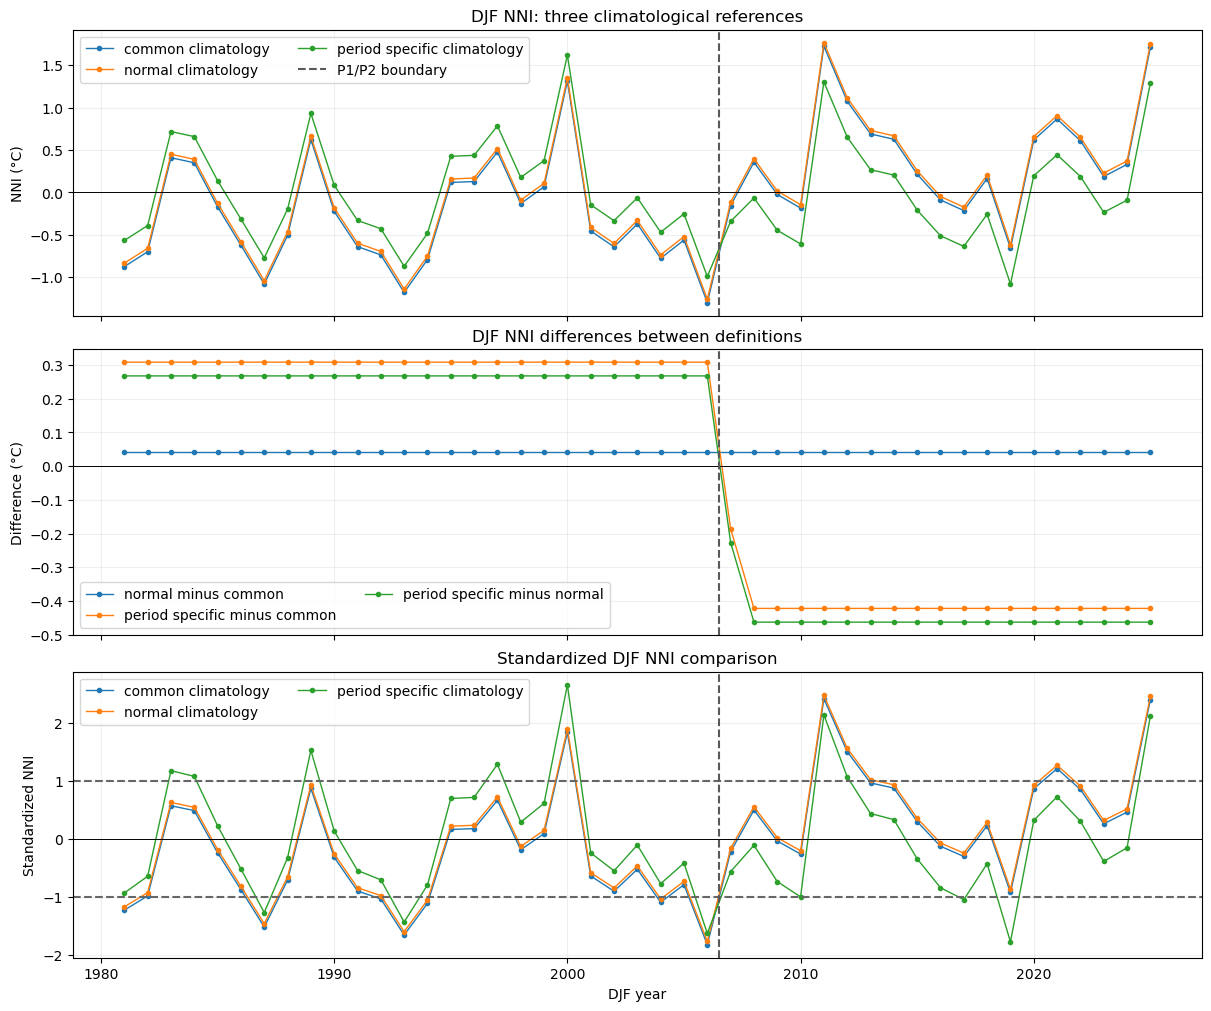

In [8]:
common_view = djf_common[['year','period','nni_djf','standardized_nni','classification']].rename(columns={'nni_djf':'nni_djf_common','standardized_nni':'standardized_common','classification':'classification_common'})
normal_view = djf_normal[['year','nni_djf','standardized_nni','classification']].rename(columns={'nni_djf':'nni_djf_normal','standardized_nni':'standardized_normal','classification':'classification_normal'})
specific_view = djf_specific[['year','nni_djf','standardized_nni','classification']].rename(columns={'nni_djf':'nni_djf_period_specific','standardized_nni':'standardized_period_specific','classification':'classification_period_specific'})
comparison = common_view.merge(normal_view,on='year').merge(specific_view,on='year')
comparison['normal_minus_common'] = comparison.nni_djf_normal - comparison.nni_djf_common
comparison['period_specific_minus_common'] = comparison.nni_djf_period_specific - comparison.nni_djf_common
comparison['period_specific_minus_normal'] = comparison.nni_djf_period_specific - comparison.nni_djf_normal
comparison['normal_vs_common_changed'] = comparison.classification_normal != comparison.classification_common
comparison['period_specific_vs_common_changed'] = comparison.classification_period_specific != comparison.classification_common
comparison['period_specific_vs_normal_changed'] = comparison.classification_period_specific != comparison.classification_normal
comparison['any_classification_changed'] = comparison[['classification_common','classification_normal','classification_period_specific']].nunique(axis=1) != 1
comparison_path = OUTPUT_DIR/'ningaloo_nino_index_DJF_climatology_comparison_1981-2025.csv'
comparison.to_csv(comparison_path,index=False)
changed = comparison[comparison.any_classification_changed]
if changed.empty: print('All classifications agree for every DJF year.')
else: display(changed)

fig,axes = plt.subplots(3,1,figsize=(12,10),sharex=True,layout='constrained')
for column,label in [('nni_djf_common','common climatology'),('nni_djf_normal','normal climatology'),('nni_djf_period_specific','period specific climatology')]: axes[0].plot(comparison.year,comparison[column],marker='o',ms=3,lw=1,label=label)
axes[0].axhline(0,color='black',lw=.7); axes[0].axvline(2006.5,color='0.35',ls='--',label='P1/P2 boundary'); axes[0].set(title='DJF NNI: three climatological references',ylabel='NNI (°C)'); axes[0].grid(alpha=.2); axes[0].legend(ncol=2)
for column,label in [('normal_minus_common','normal minus common'),('period_specific_minus_common','period specific minus common'),('period_specific_minus_normal','period specific minus normal')]: axes[1].plot(comparison.year,comparison[column],marker='o',ms=3,lw=1,label=label)
axes[1].axhline(0,color='black',lw=.7); axes[1].axvline(2006.5,color='0.35',ls='--'); axes[1].set(title='DJF NNI differences between definitions',ylabel='Difference (°C)'); axes[1].grid(alpha=.2); axes[1].legend(ncol=2)
for column,label in [('standardized_common','common climatology'),('standardized_normal','normal climatology'),('standardized_period_specific','period specific climatology')]: axes[2].plot(comparison.year,comparison[column],marker='o',ms=3,lw=1,label=label)
axes[2].axhline(0,color='black',lw=.7); axes[2].axhline(1,color='0.4',ls='--'); axes[2].axhline(-1,color='0.4',ls='--'); axes[2].axvline(2006.5,color='0.35',ls='--'); axes[2].set(title='Standardized DJF NNI comparison',xlabel='DJF year',ylabel='Standardized NNI'); axes[2].grid(alpha=.2); axes[2].legend(ncol=2)
plt.show()

## 11. Updated P1/P2 summary and three-experiment validation

The updated summary records each climatological reference period, full-series sigma used for classification, and P1/P2 DJF statistics. The validations add the 1991–2020 anomaly check and confirm all three output branches retain complete 45-season DJF series with clean CSV columns.

In [9]:
def three_way_summary(frame,experiment,reference,sigma):
    rows = []
    for period,part in frame.groupby('period',sort=False):
        rows.append({'climatology_experiment':experiment,'climatological_reference_period':reference,'full_series_sigma_for_classification':sigma,'period':period,'mean_djf_nni':part.nni_djf.mean(),'std_djf_nni_ddof1':part.nni_djf.std(ddof=1),'min_djf_nni':part.nni_djf.min(),'max_djf_nni':part.nni_djf.max(),'n_nino':int(part.classification.eq('Ningaloo Nino').sum()),'n_nina':int(part.classification.eq('Ningaloo Nina').sum()),'n_neutral':int(part.classification.eq('Neutral').sum()),'n_years':len(part)})
    return rows
summary = pd.DataFrame(three_way_summary(djf_common,'common climatology','1981-2025',sigma_common) + three_way_summary(djf_normal,'normal climatology','1991-2020',sigma_normal) + three_way_summary(djf_specific,'period specific climatology','P1: 1981-2006; P2: 2007-2025',sigma_specific))
summary_path = OUTPUT_DIR/'ningaloo_nino_climatology_experiment_summary.csv'
summary.to_csv(summary_path,index=False); display(summary)

normal_residual = float(np.abs(normal_anomaly.sel(time=slice(NORMAL_START,NORMAL_END)).groupby('time.month').mean('time',skipna=True)).max().item())
all_djf = [djf_common,djf_normal,djf_specific]
checks_three = {'normal monthly anomaly residual (°C)':normal_residual,'all experiments have 45 DJF values':all(len(frame)==45 for frame in all_djf),'all DJF seasons have three months':all((frame.n_months==3).all() for frame in all_djf),'normal CSV no index column':'Unnamed: 0' not in pd.read_csv(monthly_paths['normal climatology']).columns and 'Unnamed: 0' not in pd.read_csv(djf_paths['normal climatology']).columns,'comparison CSV no index column':'Unnamed: 0' not in pd.read_csv(comparison_path).columns,'summary CSV no index column':'Unnamed: 0' not in pd.read_csv(summary_path).columns}
for key,value in checks_three.items(): print(f'{key}: {value}')
assert normal_residual < 5e-5 and checks_three['all experiments have 45 DJF values'] and checks_three['all DJF seasons have three months']
assert checks_three['normal CSV no index column'] and checks_three['comparison CSV no index column'] and checks_three['summary CSV no index column']
print(f'\nThree-way result: sigma common={sigma_common:.6f} °C; normal={sigma_normal:.6f} °C; period specific={sigma_specific:.6f} °C.')
print(f'Maximum absolute DJF difference: normal/common={comparison.normal_minus_common.abs().max():.6f} °C; period-specific/common={comparison.period_specific_minus_common.abs().max():.6f} °C; period-specific/normal={comparison.period_specific_minus_normal.abs().max():.6f} °C.')
print(f'Years with any classification difference: {len(changed)} of {len(comparison)}. This is sensitivity evidence, not causal attribution.')

,climatology_experiment,climatological_reference_period,full_series_sigma_for_classification,period,mean_djf_nni,std_djf_nni_ddof1,min_djf_nni,max_djf_nni,n_nino,n_nina,n_neutral,n_years
0,common climatology,1981-2025,0.714791,P1,-0.318741,0.617118,-1.300007,1.311173,1,7,18,26
1,common climatology,1981-2025,0.714791,P2,0.412984,0.627259,-0.657611,1.724942,4,0,15,19
2,normal climatology,1991-2020,0.714791,P1,-0.277965,0.617118,-1.259232,1.351949,1,6,19,26
3,normal climatology,1991-2020,0.714791,P2,0.453759,0.627259,-0.616835,1.765718,5,0,14,19
4,period specific climatology,P1: 1981-2006; P2: 2007-2025,0.610308,P1,-0.010163,0.617118,-0.991429,1.619751,5,3,18,26
5,period specific climatology,P1: 1981-2006; P2: 2007-2025,0.610308,P2,0.003128,0.617618,-1.079905,1.302647,3,2,14,19


normal monthly anomaly residual (°C): 1.106262243411038e-05
all experiments have 45 DJF values: True
all DJF seasons have three months: True
normal CSV no index column: True
comparison CSV no index column: True
summary CSV no index column: True

Three-way result: sigma common=0.714791 °C; normal=0.714791 °C; period specific=0.610308 °C.
Maximum absolute DJF difference: normal/common=0.040775 °C; period-specific/common=0.422295 °C; period-specific/normal=0.463070 °C.
Years with any classification difference: 12 of 45. This is sensitivity evidence, not causal attribution.
